# 📰 AI Project Lifecycle Interactive Lab
## Predicting Viral Articles: The News Always Case

**Notebook developed by** SzuLun Huang  
**Under the guidance of** Eric Van Dusen  
**UC Berkeley, Data Science**

**Goal**: Walk through the full AI project lifecycle interactively to address declining newspaper readership.

> **This notebook reimplements in Python the AI Project Cycle originally demonstrated with Orange.**  
> Focus on the thinking process — **Problem → Data → Model → Evaluate → Deploy** — not on any specific tool UI.

---

### 🗺️ Notebook Map

| Unit | Topic | What you will learn |
|------|------|---------------------|
| **0** | Setup | Install packages |
| **1** | Problem Scoping | Turn a business problem into an AI problem |
| **2** | Data Acquisition | Synthetic dataset, features & target |
| **3** | Data Exploration | Distributions, correlations, viral vs normal |
| **4** | Underfitting vs Overfitting | Train / Validation divergence |
| **5** | Modeling | Train models + **feature importance** |
| **6** | Evaluation | Threshold, Precision / Recall / F1 |
| **7** | Bayes' Theorem Mini-Lab | Conditional probability & spam intuition |
| **8** | Live Prediction | Input new article features and see results |
| **9** | Deployment & Monitoring | What to watch after going live |
| **10** | Assignment Template + Key Takeaways | Ready for presentations |

---

### 📌 How to use
1. Menu **Runtime → Run all** (Colab) or **Kernel → Restart & Run All** (Jupyter)
2. Wait until all cells finish
3. Interact with sliders, buttons, and charts

> Designed for classroom interaction, group discussion, and assignment presentations.


## 0. Environment Setup


In [1]:
#@title Install packages
import sys
import subprocess

def install_if_missing(package):
    mod = package.split('==')[0].replace('-', '_')
    try:
        __import__(mod)
    except ImportError:
        print(f'Installing {package}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])

for pkg in ['ipywidgets', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn']:
    install_if_missing(pkg)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, clear_output, HTML, Markdown
import ipywidgets as widgets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, f1_score, precision_score, recall_score
)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✅ Environment ready.')


Installing scikit-learn...
✅ Environment ready.


---
## 1. Problem Scoping

**Scenario**: You are a data scientist at the local newspaper **News Always**.

News Always has operated for 30 years. Over the past three years, digital subscriptions have declined — especially among readers under 25. The editorial lead asks you to find **which article traits tend to be shared widely**, using data science rather than pure editorial intuition.

**Data provided**: Articles from the past two years, including title length, publish time, author, category, and final share counts.


In [2]:
#@title Guiding questions for problem scoping
scoping_box = widgets.VBox([
    widgets.HTML("<h4 style='margin-bottom:8px;'>Before any analysis, answer these questions — every real AI project should start here:</h4>"),
    widgets.HTML("""
    <ol style='line-height:1.9; font-size:15px; color:#1e293b;'>
      <li><b>What is the root problem?</b> Why are readers leaving? Weak content, or weak distribution?</li>
      <li><b>Classification or regression?</b> Predict “will it go viral?” (yes/no) or “how many shares?”</li>
      <li><b>Ethical risks?</b> Might the model over-promote sensational headlines? Bias against certain topics or authors?</li>
      <li><b>Definition of success?</b> Is accuracy enough, or do you need precision / recall?</li>
    </ol>
    """),
    widgets.HTML("<p style='color:#64748b; margin-top:12px;'>💡 Tip: Put answers to these four questions on the first slide of your presentation.</p>")
])
display(scoping_box)


---
## 2. Data Acquisition

The original course assignment provides an official **`Viral.csv`**.

To make this notebook self-contained, we first build a **synthetic dataset** that mimics “will this news article go viral?”

> ⚠️ **Important: this is not the official assignment `Viral.csv`.**  
> If you receive the official file later, replace the synthetic data below with it.

In the Data Acquisition stage, ask:

- Where does the data come from? Do we have permission to use it?
- What is the target? Here: **is_viral**.
- Which columns could be features?
- Missing values, errors, sensitive fields, or sources of bias?


In [3]:
#@title Generate synthetic dataset (Viral.csv style)
np.random.seed(42)
n_samples = 2000

syn_title_length = np.random.normal(12, 4, n_samples).clip(3, 30).astype(int)
syn_content_length = np.random.normal(650, 250, n_samples).clip(100, 2000).astype(int)
syn_num_images = np.random.poisson(2.5, n_samples).clip(0, 12)
syn_num_videos = np.random.poisson(0.4, n_samples).clip(0, 5)
syn_publish_hour = np.random.randint(0, 24, n_samples)
syn_weekday = np.random.randint(0, 7, n_samples)  # 0=Mon ... 6=Sun
syn_sentiment = np.random.normal(0.1, 0.35, n_samples).clip(-1, 1)
syn_has_clickbait = np.random.binomial(1, 0.28, n_samples)
syn_author_followers = np.random.lognormal(8.5, 1.2, n_samples).astype(int)

syn_categories = np.random.choice(
    ['Politics', 'Sports', 'Entertainment', 'Technology', 'Lifestyle', 'Business'],
    size=n_samples,
    p=[0.18, 0.15, 0.22, 0.16, 0.17, 0.12]
)

# Stronger author_followers weight so the feature is visible in models
syn_viral_score = (
    0.015 * syn_title_length +
    0.0008 * syn_content_length +
    0.18 * syn_num_images +
    0.35 * syn_num_videos +
    0.12 * ((syn_publish_hour >= 7) & (syn_publish_hour <= 10)).astype(float) +
    0.15 * (syn_weekday >= 5).astype(float) +  # weekend boost
    0.25 * syn_sentiment +
    0.45 * syn_has_clickbait +
    0.00012 * syn_author_followers +
    np.where(syn_categories == 'Entertainment', 0.3, 0) +
    np.where(syn_categories == 'Sports', 0.15, 0) +
    np.random.normal(0, 0.45, n_samples)
)

syn_is_viral = (syn_viral_score > np.percentile(syn_viral_score, 70)).astype(int)

articles_df = pd.DataFrame({
    'title_length': syn_title_length,
    'content_length': syn_content_length,
    'num_images': syn_num_images,
    'num_videos': syn_num_videos,
    'publish_hour': syn_publish_hour,
    'weekday': syn_weekday,
    'sentiment_score': np.round(syn_sentiment, 3),
    'has_clickbait': syn_has_clickbait,
    'author_followers': syn_author_followers,
    'category': syn_categories,
    'is_viral': syn_is_viral
})

print(f'Dataset size: {articles_df.shape[0]} articles, {articles_df.shape[1]} columns')
print(f'Viral rate: {articles_df["is_viral"].mean():.1%}')
print('\nFirst 8 rows:')
display(articles_df.head(8))
print('\nNote: weekday uses 0=Monday ... 6=Sunday. title_length / content_length are character counts.')


Dataset size: 2000 articles, 11 columns
Viral rate: 30.0%

First 8 rows:


,title_length,content_length,num_images,num_videos,publish_hour,weekday,sentiment_score,has_clickbait,author_followers,category,is_viral
0,13,481,1,0,9,2,0.613,0,970,Politics,0
1,11,613,3,2,17,3,0.896,0,13816,Politics,0
2,14,451,2,0,2,1,-0.285,0,9084,Politics,0
3,18,573,2,0,11,3,0.192,0,964,Politics,0
4,11,176,2,0,15,5,-0.178,0,3705,Sports,0
5,11,703,0,1,17,5,0.255,0,10543,Business,0
6,18,650,1,1,16,3,0.202,1,496,Entertainment,0
7,15,445,0,0,6,0,-0.045,1,1418,Lifestyle,0



Note: weekday uses 0=Monday ... 6=Sunday. title_length / content_length are character counts.


---
## 3. Data Exploration

Do not train a model yet.

Ask first:

> **What does the data look like? Which features may relate to the target? Any anomalies, missing values, or bias?**

> 💡 **Correlation ≠ Causation**: association does not mean the feature *causes* virality.


### Target Variable Distribution

Before looking at features, inspect the target `is_viral`.

- **What this shows**: Overall share of Normal vs Viral articles.
- **Why it matters**:
  - Extreme imbalance (e.g. 95% / 5%) makes accuracy misleading.
  - Helps decide on class weights, oversampling, or metrics like F1 / AUC.
- **Here**: ~70% Normal / 30% Viral → mild imbalance, still manageable.


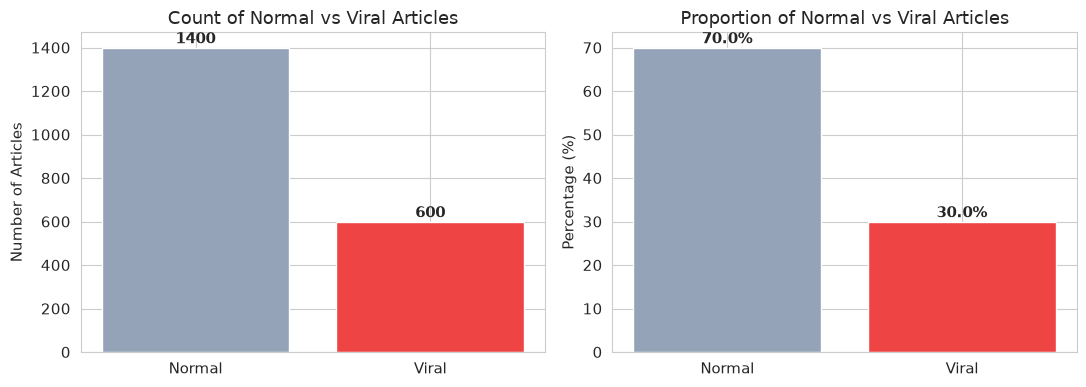

In [4]:
#@title Target distribution (Viral vs Normal)
fig_tgt, axes_tgt = plt.subplots(1, 2, figsize=(11, 4))

viral_counts = articles_df['is_viral'].value_counts().sort_index()
viral_pct = articles_df['is_viral'].value_counts(normalize=True).sort_index() * 100
tgt_labels = ['Normal', 'Viral']
tgt_colors = ['#94a3b8', '#ef4444']

axes_tgt[0].bar(tgt_labels, viral_counts.values, color=tgt_colors, edgecolor='white')
axes_tgt[0].set_title('Count of Normal vs Viral Articles')
axes_tgt[0].set_ylabel('Number of Articles')
for i, v in enumerate(viral_counts.values):
    axes_tgt[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes_tgt[1].bar(tgt_labels, viral_pct.values, color=tgt_colors, edgecolor='white')
axes_tgt[1].set_title('Proportion of Normal vs Viral Articles')
axes_tgt[1].set_ylabel('Percentage (%)')
for i, v in enumerate(viral_pct.values):
    axes_tgt[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


### Interactive Feature Exploration

Examine **one numerical feature at a time**.

- **Left (Histogram)**: Distribution of the selected feature; optionally colored by viral status.
- **Right (Boxplot)**: Compare the feature between Viral and Normal articles.

**How to use**: Pick features from the dropdown and look for differences in center, spread, and outliers.


In [14]:
#@title Interactive feature exploration
eda_feature_options = [
    'title_length', 'content_length', 'num_images', 'num_videos',
    'publish_hour', 'weekday', 'sentiment_score', 'author_followers'
]

eda_feat_dropdown = widgets.Dropdown(
    options=eda_feature_options,
    value='title_length',
    description='Feature:',
    style={'description_width': '70px'},
    layout=widgets.Layout(width='280px')
)
eda_show_by_viral = widgets.Checkbox(value=True, description='Color by viral status')
eda_out = widgets.Output()

def eda_update_plot(change=None):
    with eda_out:
        clear_output(wait=True)
        col = eda_feat_dropdown.value
        fig_eda, axes_eda = plt.subplots(1, 2, figsize=(12, 4.2))

        if eda_show_by_viral.value:
            for label, color in [(0, '#94a3b8'), (1, '#ef4444')]:
                subset = articles_df.loc[articles_df['is_viral'] == label, col]
                axes_eda[0].hist(subset, bins=25, alpha=0.65, color=color,
                                 label='Normal' if label == 0 else 'Viral', edgecolor='white')
            axes_eda[0].legend()
        else:
            axes_eda[0].hist(articles_df[col], bins=25, color='#3b82f6', edgecolor='white')
        axes_eda[0].set_title(f'Histogram: {col}')
        axes_eda[0].set_xlabel(col)

        data_box = [
            articles_df.loc[articles_df['is_viral'] == 0, col],
            articles_df.loc[articles_df['is_viral'] == 1, col]
        ]
        bp = axes_eda[1].boxplot(data_box, tick_labels=['Normal', 'Viral'], patch_artist=True)
        for patch, color in zip(bp['boxes'], ['#94a3b8', '#ef4444']):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        axes_eda[1].set_title(f'Boxplot: {col} by Viral Status')
        axes_eda[1].set_ylabel(col)

        plt.tight_layout()
        plt.show()

eda_feat_dropdown.observe(eda_update_plot, names='value')
eda_show_by_viral.observe(eda_update_plot, names='value')
display(widgets.HBox([eda_feat_dropdown, eda_show_by_viral]))
display(eda_out)
eda_update_plot()


Output()

### Category Viral Rate & Feature Correlation

**Left – Viral rate by category**  
Share of viral articles in each content category.

**Right – Correlation with `is_viral`**  
Linear correlation between each numerical feature and the target.
- Positive → higher feature value tends to be more viral
- Near 0 → weak linear relationship

**Note**: Correlation only captures linear patterns; non-linear effects may still exist.


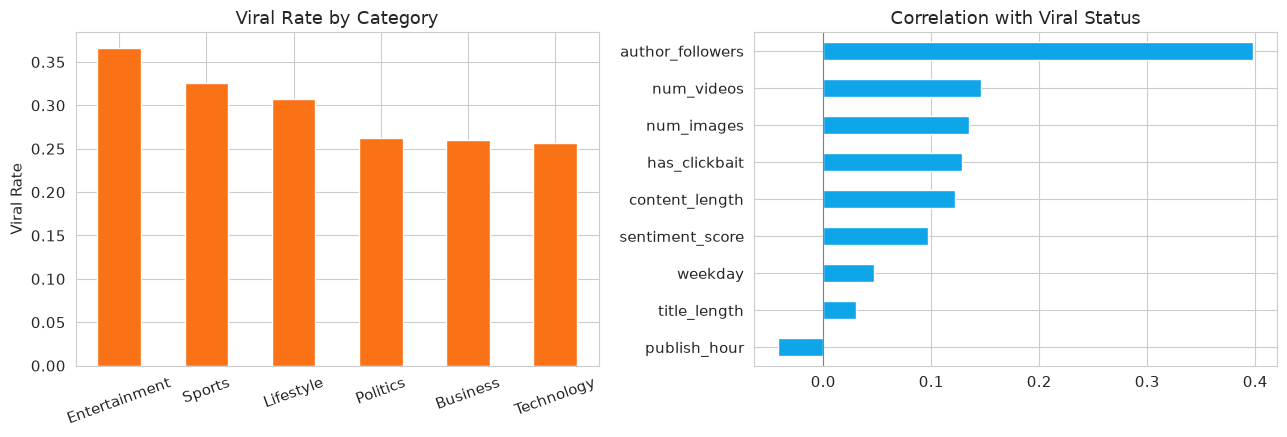

💡 Key insight: Which features relate more to "Viral"? That will guide modeling and feature focus later.


In [6]:
#@title Category viral rate & correlation with target
fig_cat, axes_cat = plt.subplots(1, 2, figsize=(13, 4.5))

cat_viral_rate = articles_df.groupby('category')['is_viral'].mean().sort_values(ascending=False)
cat_viral_rate.plot(kind='bar', ax=axes_cat[0], color='#f97316', edgecolor='white')
axes_cat[0].set_title('Viral Rate by Category')
axes_cat[0].set_ylabel('Viral Rate')
axes_cat[0].set_xlabel('')
axes_cat[0].tick_params(axis='x', rotation=20)

num_cols_corr = [
    'title_length', 'content_length', 'num_images', 'num_videos',
    'publish_hour', 'weekday', 'sentiment_score', 'has_clickbait',
    'author_followers', 'is_viral'
]
corr_with_viral = articles_df[num_cols_corr].corr()['is_viral'].drop('is_viral').sort_values()
corr_with_viral.plot(kind='barh', ax=axes_cat[1], color='#0ea5e9')
axes_cat[1].set_title('Correlation with Viral Status')
axes_cat[1].axvline(0, color='gray', linewidth=0.8)

plt.tight_layout()
plt.show()
print('💡 Key insight: Which features relate more to "Viral"? That will guide modeling and feature focus later.')


### Full Correlation Heatmap

Pairwise correlations among numerical features (including the target).


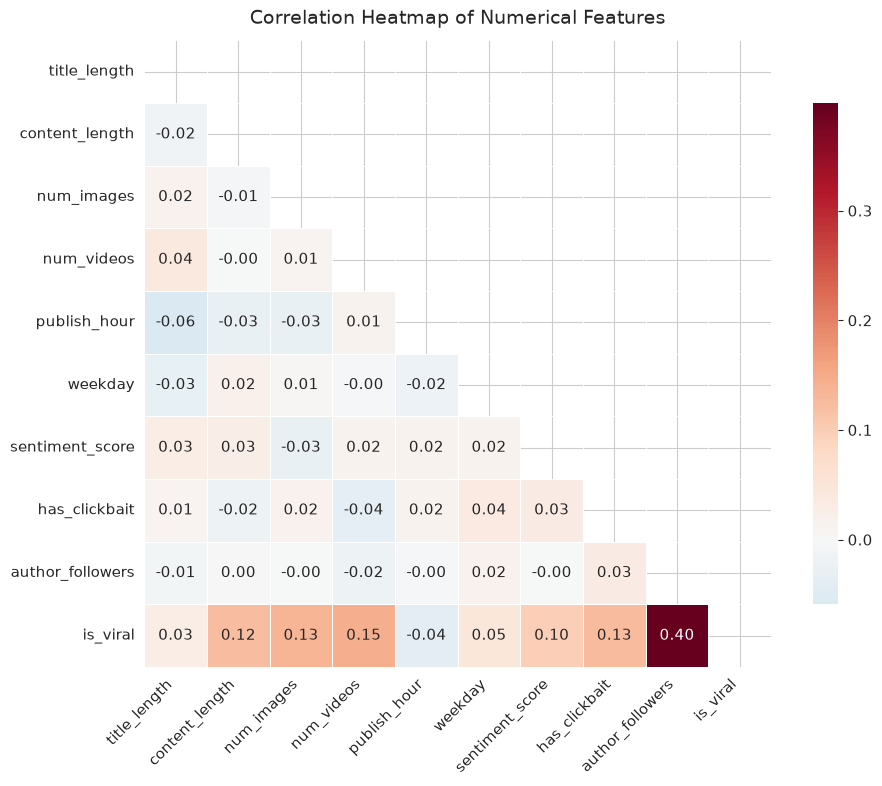

In [7]:
#@title Full correlation heatmap
heatmap_cols = [
    'title_length', 'content_length', 'num_images', 'num_videos',
    'publish_hour', 'weekday', 'sentiment_score', 'has_clickbait',
    'author_followers', 'is_viral'
]
corr_matrix = articles_df[heatmap_cols].corr()

fig_hm, ax_hm = plt.subplots(figsize=(10, 8))
mask_hm = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    mask=mask_hm,
    ax=ax_hm
)
ax_hm.set_title('Correlation Heatmap of Numerical Features', fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


---
## 4. Underfitting vs Overfitting: Good on Train Is Not Enough

What matters is:

> **Does the model still work on data it has never seen?**

- **Underfitting**: Train and validation both poor → model too simple
- **Good fit**: Train good, validation good → generalizes
- **Overfitting**: Train keeps improving, validation worsens → memorizing noise

> 💡 **This polynomial regression demo illustrates under/overfitting.**  
> Use the same mindset later when you look at Train vs Test scores on the real article model.


In [8]:
#@title Polynomial degree slider: watch Train vs Validation
np.random.seed(0)
poly_X_all = np.sort(np.random.rand(70, 1) * 6 - 1, axis=0)
poly_y_all = np.sin(poly_X_all).ravel() + np.random.normal(0, 0.25, poly_X_all.shape[0])

poly_X_train, poly_X_val, poly_y_train, poly_y_val = train_test_split(
    poly_X_all, poly_y_all, test_size=0.35, random_state=42
)

poly_degree_slider = widgets.IntSlider(
    value=1, min=1, max=15, step=1,
    description='Complexity:',
    style={'description_width': '90px'},
    continuous_update=False,
    layout=widgets.Layout(width='420px')
)
poly_out = widgets.Output()

def poly_plot_fit(change=None):
    with poly_out:
        clear_output(wait=True)
        degree = poly_degree_slider.value
        poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
        poly_model.fit(poly_X_train, poly_y_train)

        X_plot = np.linspace(poly_X_all.min() - 0.3, poly_X_all.max() + 0.3, 300).reshape(-1, 1)
        y_plot = poly_model.predict(X_plot)

        train_score = poly_model.score(poly_X_train, poly_y_train)
        val_score = poly_model.score(poly_X_val, poly_y_val)
        gap = train_score - val_score

        fig_poly, ax_poly = plt.subplots(figsize=(9, 5))
        ax_poly.scatter(poly_X_train, poly_y_train, s=48, label='Training data', alpha=0.85)
        ax_poly.scatter(poly_X_val, poly_y_val, s=55, marker='x', label='Validation data')
        ax_poly.plot(X_plot, y_plot, linewidth=2.5, label=f'Model (degree={degree})')
        ax_poly.set_ylim(-2.2, 2.2)
        ax_poly.set_title(f'Train R² = {train_score:.3f}   |   Val R² = {val_score:.3f}   |   Gap = {gap:.3f}')
        ax_poly.legend(loc='upper right')

        if degree <= 2:
            status, color = 'Underfitting — model is too simple', '#3b82f6'
        elif degree <= 6:
            status, color = 'Good fit — Train & Val both look decent', '#22c55e'
        else:
            status, color = 'Overfitting — Train improves, Val gets worse', '#ef4444'

        ax_poly.text(
            0.02, 0.05, status, transform=ax_poly.transAxes, fontsize=12, color=color,
            fontweight='bold', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9)
        )
        plt.tight_layout()
        plt.show()
        print('Drag the slider. Watch when the Gap (Train − Val) starts growing — that is overfitting.')

poly_degree_slider.observe(poly_plot_fit, names='value')
display(poly_degree_slider)
display(poly_out)
poly_plot_fit()


IntSlider(value=1, continuous_update=False, description='Complexity:', layout=Layout(width='420px'), max=15, m…

Output()

## 5. Modeling + Feature Importance

Train models to predict whether an article will go viral.

After training, scroll to **Unit 6 (Threshold playground)** and adjust the decision threshold with the model you just trained.

---

### Why these three models?

| Model | Type | Strengths | Weaknesses | Good when |
|------|------|-----------|------------|-----------|
| **Logistic Regression** | Linear | Fast, interpretable, less prone to overfit | Only linear relationships | Need a quick baseline |
| **Decision Tree** | Tree | Easy to read rules, handles non-linearity | Overfits easily, unstable | Want transparent rules |
| **Random Forest** | Ensemble of trees | Usually stronger, more stable, feature importance | Slower, less transparent | Want a solid baseline |

**Quick picks**
- Fast baseline → Logistic Regression  
- Want rules → Decision Tree  
- Best of the three on average → Random Forest  

### Max depth (Decision Tree / Random Forest only)
- Too small → underfitting  
- Too large → overfitting  
- Start around 5 and adjust while watching scores and feature importance  

### Metrics (default threshold = 0.5)

| Metric | Meaning | When it matters |
|--------|---------|-----------------|
| **Accuracy** | Overall correct rate | Classes roughly balanced |
| **Precision** | Of predicted Viral, how many truly are | Cost of false alarms (FP) is high |
| **Recall** | Of true Viral, how many you caught | Cost of misses (FN) is high |
| **F1** | Balance of Precision & Recall | Imbalance; both errors matter |

Our data is ~70% / 30%. Predicting “always Normal” already gets 70% accuracy — so look at Precision, Recall, and F1, not only Accuracy.


In [9]:
#@title Prepare data + select model + feature importance
model_df = articles_df.copy()
category_encoder = LabelEncoder()
model_df['category_encoded'] = category_encoder.fit_transform(model_df['category'])

feature_cols = [
    'title_length', 'content_length', 'num_images', 'num_videos',
    'publish_hour', 'weekday', 'sentiment_score', 'has_clickbait',
    'author_followers', 'category_encoded'
]

X_all = model_df[feature_cols]
y_all = model_df['is_viral']

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=42, stratify=y_all
)

print(f'Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples  |  Features: {X_train.shape[1]}')

model_dropdown = widgets.Dropdown(
    options=[
        ('Logistic Regression', 'lr'),
        ('Decision Tree', 'dt'),
        ('Random Forest', 'rf')
    ],
    value='rf',
    description='Model:',
    style={'description_width': '70px'},
    layout=widgets.Layout(width='300px')
)
max_depth_slider = widgets.IntSlider(
    value=5, min=1, max=20, step=1,
    description='Max Depth:',
    style={'description_width': '80px'},
    continuous_update=False
)
train_btn = widgets.Button(
    description='Train Model',
    button_style='success',
    layout=widgets.Layout(width='140px', height='36px')
)
train_out = widgets.Output()

# Shared state for later units (evaluation & live prediction)
trained_model = None
trained_feature_cols = feature_cols
trained_label_encoder = category_encoder
trained_metric_prob = None
trained_model_name = None
trained_max_depth = None

def train_model_handler(btn=None):
    global trained_model, trained_metric_prob, trained_model_name, trained_max_depth
    with train_out:
        clear_output(wait=True)
        model_type = model_dropdown.value
        depth = max_depth_slider.value

        if model_type == 'lr':
            clf = LogisticRegression(max_iter=1000, random_state=42)
            name = 'Logistic Regression'
            depth_used = None
        elif model_type == 'dt':
            clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
            name = f'Decision Tree (max_depth={depth})'
            depth_used = depth
        else:
            clf = RandomForestClassifier(
                n_estimators=100, max_depth=depth, random_state=42, n_jobs=-1
            )
            name = f'Random Forest (max_depth={depth})'
            depth_used = depth

        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:, 1]

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)

        print(f'Model trained: {name}\n')
        print('Test set performance (threshold = 0.5)')
        print(f'  Accuracy  : {acc:.3f}')
        print(f'  Precision : {prec:.3f}')
        print(f'  Recall    : {rec:.3f}')
        print(f'  F1 Score  : {f1:.3f}')

        fig_model, axes_model = plt.subplots(1, 2, figsize=(13, 4.8))

        if hasattr(clf, 'feature_importances_'):
            imp = pd.Series(clf.feature_importances_, index=feature_cols).sort_values()
            imp.plot(kind='barh', ax=axes_model[0], color='#8b5cf6')
            axes_model[0].set_title('Feature Importance')
            axes_model[0].set_xlabel('Importance Score')
        elif hasattr(clf, 'coef_'):
            coef = pd.Series(np.abs(clf.coef_[0]), index=feature_cols).sort_values()
            coef.plot(kind='barh', ax=axes_model[0], color='#8b5cf6')
            axes_model[0].set_title('|Coefficient| (absolute value)')
            axes_model[0].set_xlabel('|Coefficient|')
        else:
            axes_model[0].text(0.5, 0.5, 'No feature importance available', ha='center', va='center')
            axes_model[0].set_axis_off()

        cm = confusion_matrix(y_test, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Viral']).plot(
            ax=axes_model[1], cmap='Blues', colorbar=False
        )
        axes_model[1].set_title('Confusion Matrix (threshold=0.5)')

        plt.tight_layout()
        plt.show()

        trained_model = clf
        trained_metric_prob = y_prob
        trained_model_name = name
        trained_max_depth = depth_used

        print('\nNext: scroll to Unit 6 and play with the Threshold slider.')
        print('Tip: try different max_depth values and re-train to watch overfitting and feature importance.')

train_btn.on_click(train_model_handler)
display(widgets.HBox([model_dropdown, max_depth_slider, train_btn]))
display(train_out)
print('Select a model and click "Train Model".')


Train: 1500 samples  |  Test: 500 samples  |  Features: 10


Output()

Select a model and click "Train Model".


---
## 6. Evaluation: How to Choose a Threshold

> ⚠️ **Order matters: this unit needs the model from Unit 5.**  
> Go to Unit 5, pick a model, click **Train Model**, then come back.  
> If you Ran all and see “Please train a model…”, just re-click Train Model in Unit 5.

The model outputs a **probability**. The threshold decides how high the probability must be to call an article Viral.

- Lower threshold → catch more → usually **Recall ↑, FP ↑**
- Higher threshold → stricter → usually **Precision ↑, FN ↑**


In [10]:
#@title Metric playground: adjust threshold
threshold_slider = widgets.FloatSlider(
    value=0.50, min=0.05, max=0.95, step=0.05,
    description='Threshold:',
    style={'description_width': '90px'},
    continuous_update=False,
    layout=widgets.Layout(width='420px')
)
btn_balanced = widgets.Button(description='Balanced (0.50)', layout=widgets.Layout(width='140px'))
btn_high_recall = widgets.Button(description='High Recall (0.25)', layout=widgets.Layout(width='150px'))
btn_high_prec = widgets.Button(description='High Precision (0.75)', layout=widgets.Layout(width='160px'))
metric_out = widgets.Output()

def metric_card_html(name, value, question, memory):
    return f"""
    <div style="flex:1;min-width:160px;padding:10px 12px;border:1px solid #cbd5e1;
                border-radius:10px;background:white;">
      <div style="font-size:12px;color:#64748b;font-weight:700;">{name}</div>
      <div style="font-size:27px;font-weight:800;color:#0f172a;margin:3px 0;">{value:.3f}</div>
      <div style="font-size:12px;color:#475569;">{question}</div>
      <div style="font-size:11px;color:#2563eb;margin-top:5px;"><b>{memory}</b></div>
    </div>
    """

def update_metrics(change=None):
    with metric_out:
        clear_output(wait=True)
        if trained_metric_prob is None:
            print('Please train a model in Unit 5 first, then come back here.')
            return

        t = threshold_slider.value
        pred = (trained_metric_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()

        acc = accuracy_score(y_test, pred)
        prec = precision_score(y_test, pred, zero_division=0)
        rec = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)

        fpr_curve, tpr_curve, _ = roc_curve(y_test, trained_metric_prob)
        roc_auc = auc(fpr_curve, tpr_curve)

        display(HTML(f"""
        <div style="max-width:900px;">
          <div style="padding:12px 15px;background:#eff6ff;border:1px solid #93c5fd;
                      border-radius:10px;margin-bottom:12px;line-height:1.6;">
            <b>Current Threshold = {t:.2f}</b><br>
            Probability ≥ {t:.2f} → predicted as <b>Viral (Positive)</b>.<br>
            Lower threshold → catch more → usually <b>Recall ↑, FP ↑</b><br>
            Higher threshold → more strict → usually <b>Precision ↑, FN ↑</b>
          </div>
          <div style="display:flex;gap:10px;flex-wrap:wrap;">
            {metric_card_html("Accuracy", acc, "How many did I get right overall?", "Overall correctness")}
            {metric_card_html("Precision", prec, "Of those I called Viral, how many truly are?", "Avoid false alarms (FP)")}
            {metric_card_html("Recall", rec, "Of all real Viral cases, how many did I catch?", "Avoid missing them (FN)")}
            {metric_card_html("F1", f1, "How well are Precision & Recall balanced?", "When both matter")}
          </div>
        </div>
        """))

        fig_met, axes_met = plt.subplots(1, 2, figsize=(12, 4.5))
        cm = np.array([[tn, fp], [fn, tp]])
        ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Viral']).plot(
            ax=axes_met[0], cmap='Blues', colorbar=False
        )
        axes_met[0].set_title(f'Confusion Matrix @ threshold={t:.2f}\nFP={fp}  |  FN={fn}')

        axes_met[1].plot(fpr_curve, tpr_curve, lw=2, label=f'ROC-AUC = {roc_auc:.3f}')
        axes_met[1].plot([0, 1], [0, 1], '--', lw=1)
        axes_met[1].set_xlabel('False Positive Rate')
        axes_met[1].set_ylabel('True Positive Rate (Recall)')
        axes_met[1].set_title('ROC Curve (all thresholds)')
        axes_met[1].legend(loc='lower right')

        plt.tight_layout()
        plt.show()

        if t <= 0.30:
            lesson = 'You are favoring Recall: better to catch more, even with some false alarms.'
        elif t >= 0.70:
            lesson = 'You are favoring Precision: only predict Viral when quite sure, fewer false alarms.'
        else:
            lesson = 'Balanced range: watch the trade-off among Precision, Recall, and F1.'

        display(HTML(f"""
        <div style="max-width:860px;padding:12px 15px;border-left:5px solid #2563eb;
                    background:#f8fafc;line-height:1.7;">
          <b>{lesson}</b><br><br>
          <b>Key reminders:</b><br>
          • Precision denominator = cases you predicted Positive (TP + FP)<br>
          • Recall denominator = actual Positive cases (TP + FN)<br>
          • F1 = harmonic mean of Precision and Recall<br>
          • ROC-AUC = ranking ability across thresholds (not tied to one cutoff)
        </div>
        """))

def set_threshold(v):
    def handler(_):
        threshold_slider.value = v
    return handler

btn_balanced.on_click(set_threshold(0.50))
btn_high_recall.on_click(set_threshold(0.25))
btn_high_prec.on_click(set_threshold(0.75))
threshold_slider.observe(update_metrics, names='value')

display(HTML("""
<div style="max-width:850px;margin-bottom:8px;">
  <b>Task:</b> Try the three scenario buttons first, then drag the slider.<br>
  Do not only look at scores — watch how <b>FP and FN trade off</b>.
</div>
"""))
display(widgets.HBox([btn_balanced, btn_high_recall, btn_high_prec]))
display(threshold_slider)
display(metric_out)
update_metrics()


FloatSlider(value=0.5, continuous_update=False, description='Threshold:', layout=Layout(width='420px'), max=0.…

Output()

### 🧪 Can you pick the right metric?

Answer without looking first:

1. **Cancer screening**: missing a patient is worst → prioritize?
2. **Spam filter**: marking a real important email as spam is worst → prioritize?
3. **Rare positives; both precision and recall matter** → convenient single score?
4. **No production threshold yet; compare two classifiers on ranking** → look at?
5. **Classes balanced; FP and FN costs similar** → most intuitive metric?

<details>
<summary><b>👀 Click for answers</b></summary>

1. **Recall** — fear FN; catch more rather than miss  
2. **Precision** — fear FP; do not flag wrongly  
3. **F1** — both precision and recall matter  
4. **ROC-AUC** — overall discrimination / ranking across thresholds  
5. **Accuracy** — balanced classes and similar error costs

</details>


---
## 7. Bayes' Theorem Mini-Lab

Bayes' theorem describes **how to update beliefs after new evidence**:

$$P(A|B) = \frac{P(B|A)\,P(A)}{P(B)}$$

In a spam-filter intuition:

- $P(\text{Spam})$: prior  
- $P(\text{keyword} \mid \text{Spam})$: likelihood  
- $P(\text{Spam} \mid \text{keyword})$: posterior  

Use the sliders to see how the posterior changes.

> 💡 **Naive Bayes classifiers** apply this “prior + likelihood → posterior” idea across many features (many keywords).


In [11]:
#@title Bayes: spam keyword experiment
bayes_prior_slider = widgets.FloatSlider(
    value=0.20, min=0.01, max=0.80, step=0.01,
    description='P(Spam):',
    style={'description_width': '100px'},
    continuous_update=False,
    layout=widgets.Layout(width='420px')
)
bayes_lik_spam = widgets.FloatSlider(
    value=0.70, min=0.05, max=0.95, step=0.01,
    description='P(KW|Spam):',
    style={'description_width': '110px'},
    continuous_update=False,
    layout=widgets.Layout(width='420px')
)
bayes_lik_ham = widgets.FloatSlider(
    value=0.05, min=0.01, max=0.50, step=0.01,
    description='P(KW|Ham):',
    style={'description_width': '110px'},
    continuous_update=False,
    layout=widgets.Layout(width='420px')
)
bayes_out = widgets.Output()

def update_bayes(change=None):
    with bayes_out:
        clear_output(wait=True)
        p_spam = bayes_prior_slider.value
        p_ham = 1 - p_spam
        p_kw_spam = bayes_lik_spam.value
        p_kw_ham = bayes_lik_ham.value

        p_kw = p_kw_spam * p_spam + p_kw_ham * p_ham
        p_spam_given_kw = (p_kw_spam * p_spam) / p_kw if p_kw > 0 else 0

        print(f'Prior  P(Spam)              = {p_spam:.2%}')
        print(f'Likelihood P(KW | Spam)     = {p_kw_spam:.2%}')
        print(f'Likelihood P(KW | Ham)      = {p_kw_ham:.2%}')
        print(f'P(Keyword appears)          = {p_kw:.2%}')
        print()
        print(f'Posterior P(Spam | Keyword) = {p_spam_given_kw:.2%}')

        fig_bayes, ax_bayes = plt.subplots(figsize=(8, 3.8))
        bars = ax_bayes.bar(
            ['Prior\nP(Spam)', 'Posterior\nP(Spam|Keyword)'],
            [p_spam, p_spam_given_kw],
            color=['#94a3b8', '#ef4444'],
            width=0.5
        )
        ax_bayes.set_ylim(0, 1.05)
        ax_bayes.set_ylabel('Probability')
        ax_bayes.set_title('How does belief update after seeing a spam keyword?')
        for bar, val in zip(bars, [p_spam, p_spam_given_kw]):
            ax_bayes.text(bar.get_x() + bar.get_width() / 2, val + 0.03,
                          f'{val:.1%}', ha='center', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

        if p_spam_given_kw > 0.8:
            msg = 'The system is now quite confident this is spam.'
        elif p_spam_given_kw > 0.5:
            msg = 'The system leans toward spam, but some uncertainty remains.'
        else:
            msg = 'Even with the keyword, the posterior is not high (keyword may also appear in normal mail).'
        print(f'\n{msg}')
        print('This is the core intuition behind the Naive Bayes classifier.')

for w in [bayes_prior_slider, bayes_lik_spam, bayes_lik_ham]:
    w.observe(update_bayes, names='value')

display(bayes_prior_slider)
display(bayes_lik_spam)
display(bayes_lik_ham)
display(bayes_out)
update_bayes()


FloatSlider(value=0.2, continuous_update=False, description='P(Spam):', layout=Layout(width='420px'), max=0.8,…

FloatSlider(value=0.7, continuous_update=False, description='P(KW|Spam):', layout=Layout(width='420px'), max=0…

FloatSlider(value=0.05, continuous_update=False, description='P(KW|Ham):', layout=Layout(width='420px'), max=0…

Output()

---
## 8. Live Prediction (Try Your Model)

Enter features for a new article and see the model’s prediction.
Requires a trained model from Unit 5.


In [12]:
#@title Input features for a new article
pred_title_w = widgets.IntSlider(value=14, min=3, max=30, description='Title length')
pred_content_w = widgets.IntSlider(value=600, min=100, max=2000, step=50, description='Content len')
pred_images_w = widgets.IntSlider(value=3, min=0, max=12, description='Images')
pred_videos_w = widgets.IntSlider(value=0, min=0, max=5, description='Videos')
pred_hour_w = widgets.IntSlider(value=9, min=0, max=23, description='Publish hour')
pred_weekday_w = widgets.Dropdown(
    options=[(d, i) for i, d in enumerate(
        ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    )],
    value=0, description='Weekday'
)
pred_sentiment_w = widgets.FloatSlider(value=0.2, min=-1.0, max=1.0, step=0.05, description='Sentiment')
pred_clickbait_w = widgets.Checkbox(value=False, description='Sensational title?')
pred_followers_w = widgets.IntSlider(value=3000, min=100, max=100000, step=500, description='Followers')
pred_category_w = widgets.Dropdown(
    options=['Politics', 'Sports', 'Entertainment', 'Technology', 'Lifestyle', 'Business'],
    value='Entertainment', description='Category'
)
pred_btn = widgets.Button(
    description='🔮 Predict viral?',
    button_style='primary',
    layout=widgets.Layout(width='180px', height='38px')
)
pred_out = widgets.Output()

def do_predict(btn):
    with pred_out:
        clear_output(wait=True)
        if trained_model is None:
            print('⚠️ Please train a model in Unit 5 first.')
            return

        print(f'📌 Current model: {trained_model_name}')

        cat_enc = trained_label_encoder.transform([pred_category_w.value])[0]
        row = pd.DataFrame([[
            pred_title_w.value, pred_content_w.value, pred_images_w.value, pred_videos_w.value,
            pred_hour_w.value, pred_weekday_w.value, pred_sentiment_w.value,
            int(pred_clickbait_w.value), pred_followers_w.value, cat_enc
        ]], columns=trained_feature_cols)

        pred = trained_model.predict(row)[0]
        prob = trained_model.predict_proba(row)[0][1]

        if pred == 1:
            print('🔥 Prediction: this article is likely to go **viral**.')
        else:
            print('📄 Prediction: this article is more likely **normal**.')
        print(f'\nModel confidence (P(viral)): {prob:.1%}')
        bar_len = int(prob * 30)
        print('[' + '█' * bar_len + '░' * (30 - bar_len) + ']')

        reasons = []
        if pred_videos_w.value >= 2:
            reasons.append(f'more videos ({pred_videos_w.value})')
        if pred_clickbait_w.value:
            reasons.append('sensational title')
        if pred_category_w.value == 'Entertainment':
            reasons.append('Entertainment category')
        if pred_followers_w.value >= 10000:
            reasons.append(f'high follower count ({pred_followers_w.value:,})')
        if pred_images_w.value >= 4:
            reasons.append(f'more images ({pred_images_w.value})')
        if pred_sentiment_w.value >= 0.4:
            reasons.append(f'positive sentiment ({pred_sentiment_w.value:.2f})')
        if 7 <= pred_hour_w.value <= 10:
            reasons.append('morning publish window')
        if pred_weekday_w.value >= 5:
            reasons.append('weekend publish')

        print()
        if reasons:
            print('💡 Factors that may raise viral probability: ' + '; '.join(reasons))
        else:
            print('💡 Features look neutral. Try more videos, a sensational title, or Entertainment category.')

pred_btn.on_click(do_predict)
pred_ui = widgets.VBox([
    widgets.HTML('<h4 style="margin-bottom:10px;">Simulate a new article</h4>'),
    widgets.HBox([pred_title_w, pred_content_w]),
    widgets.HBox([pred_images_w, pred_videos_w]),
    widgets.HBox([pred_hour_w, pred_weekday_w]),
    widgets.HBox([pred_sentiment_w, pred_followers_w]),
    widgets.HBox([pred_category_w, pred_clickbait_w]),
    pred_btn, pred_out
])
display(pred_ui)


---
## 9. Deployment & Monitoring

After training and evaluation, the real work begins: **keeping performance after launch**.

### How to deploy
- **Batch scoring**: hourly/daily, score new articles and rank by viral probability for editors  
- **Live suggestion**: editors see a score while writing the headline  
- **Human in the loop**: model ranks and suggests; humans decide (reduces ethical and error risk)

### What to monitor after launch
1. **Data drift** — input feature distributions shift over time  
2. **Concept drift** — same features stop meaning “viral” the same way  
3. **Scheduled retraining** — e.g. weekly/monthly with fresh labels  
4. **Error case review** — sample FP / FN regularly  
5. **Business metrics** — did shares / reads improve when editors used the model?

> 💡 Deployment is not the end; it is the start of another loop: monitor → diagnose → return to data and modeling.


---
## 10. AI Project Lifecycle Assignment Template

Fill this table into your presentation — it is the backbone of the assignment.


In [13]:
display(HTML("""
<div style="background:#f8fafc; border:1px solid #e2e8f0; border-radius:12px; padding:20px 24px; font-family:sans-serif;">
  <h3 style="margin-top:0; color:#0f172a;">AI Project Lifecycle — Assignment Template</h3>
  <table style="width:100%; border-collapse:collapse; font-size:14px;">
    <tr style="background:#e0f2fe;">
      <th style="padding:10px; text-align:left; width:22%;">Stage</th>
      <th style="padding:10px; text-align:left;">What you should answer / show</th>
    </tr>
    <tr>
      <td style="padding:10px; border-bottom:1px solid #e2e8f0;"><b>1. Problem Scoping</b></td>
      <td style="padding:10px; border-bottom:1px solid #e2e8f0;">Root problem? Classification or regression? Ethical risks? Success criteria?</td>
    </tr>
    <tr>
      <td style="padding:10px; border-bottom:1px solid #e2e8f0;"><b>2. Data Acquisition</b></td>
      <td style="padding:10px; border-bottom:1px solid #e2e8f0;">Data source? Key features? Completeness and cleanliness?</td>
    </tr>
    <tr>
      <td style="padding:10px; border-bottom:1px solid #e2e8f0;"><b>3. Data Exploration</b></td>
      <td style="padding:10px; border-bottom:1px solid #e2e8f0;">Charts of distributions, correlations, viral vs normal (screenshots from this notebook are fine)</td>
    </tr>
    <tr>
      <td style="padding:10px; border-bottom:1px solid #e2e8f0;"><b>4. Modeling</b></td>
      <td style="padding:10px; border-bottom:1px solid #e2e8f0;">Which models? Why? Parameter tuning? Feature importance? Signs of overfitting?</td>
    </tr>
    <tr>
      <td style="padding:10px; border-bottom:1px solid #e2e8f0;"><b>5. Evaluation</b></td>
      <td style="padding:10px; border-bottom:1px solid #e2e8f0;">Accuracy / Precision / Recall / F1 / confusion matrix / ROC; how did you choose the threshold?</td>
    </tr>
    <tr>
      <td style="padding:10px;"><b>6. Deployment</b></td>
      <td style="padding:10px;">How will the model be used? How will you monitor data / concept drift? Retrain cadence?</td>
    </tr>
  </table>
  <p style="margin-bottom:0; color:#64748b; font-size:13px; margin-top:14px;">
    Suggested talk time: 5–10 minutes. Emphasize thinking process and evaluation screenshots.<br>
    <b>Bonus:</b> Write down phenomena you actually observed in this notebook
    (e.g. which feature ranked highest; how FP/FN changed at thresholds 0.25 vs 0.75;
    at which degree / max_depth overfitting started).
  </p>
</div>
"""))


Stage,What you should answer / show
1. Problem Scoping,Root problem? Classification or regression? Ethical risks? Success criteria?
2. Data Acquisition,Data source? Key features? Completeness and cleanliness?
3. Data Exploration,"Charts of distributions, correlations, viral vs normal (screenshots from this notebook are fine)"
4. Modeling,Which models? Why? Parameter tuning? Feature importance? Signs of overfitting?
5. Evaluation,Accuracy / Precision / Recall / F1 / confusion matrix / ROC; how did you choose the threshold?
6. Deployment,How will the model be used? How will you monitor data / concept drift? Retrain cadence?


---
## 11. Key Takeaways

| Concept | One sentence to remember |
|---------|--------------------------|
| **AI Project Cycle** | Problem → Data → Explore → Model → Evaluate → Deploy |
| **Classification vs Regression** | Predict “which class” vs “how much” |
| **Underfitting** | Even train performance is poor |
| **Overfitting** | Train looks great; new data looks worse |
| **Feature Importance** | Which features actually drive predictions? |
| **Accuracy** | Of all cases, how many did I get right? |
| **Precision** | **Fear FP**: of those I called positive, how many truly are? |
| **Recall** | **Fear FN**: of true positives, how many did I catch? |
| **F1** | Single score when both precision and recall matter |
| **ROC-AUC** | Ranking ability without fixing one threshold |
| **Threshold** | Not the model itself — the cutoff that turns probability into Yes/No |
| **Bayes** | Update prior beliefs with new evidence → posterior |
| **Deployment** | Monitor drift and retrain regularly |

### Formulas once more

$$
Precision = \frac{TP}{TP+FP} \quad\text{(denominator = everything you called Positive)}
$$

$$
Recall = \frac{TP}{TP+FN} \quad\text{(denominator = everything that truly is Positive)}
$$

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

> If you forget a formula, draw the confusion matrix first and ask: “What is my denominator?”

---

### Try these three experiments

1. Threshold **0.25** → watch Recall and FP  
2. Threshold **0.75** → watch Precision and FN  
3. Change Decision Tree / Random Forest **max_depth** → watch Train/Test split and feature importance  

True understanding of metrics is not memorizing definitions. It is noticing:

> **Which error do I refuse to make — FP or FN? → That decides which metric matters.**

Good luck with your presentations!
